# Contact Tracing Network Analysis

## Table of Contents
1. [Data Preprocessing](#1-data-preprocessing)
   - [1.1 Process Source Datasets](#11-process-source-datasets)
   - [1.2 Compile All Merged Datasets](#12-compile-all-merged-datasets)
   - [1.3 Final Data Preprocessing](#13-final-data-preprocessing)
2. [Data Exploration](#2-data-exploration)
   - [2.1 Imports](#21-imports)
   - [2.2 Network Structure Analysis](#22-network-structure-analysis)
   - [2.3 Degree Distribution Analysis](#23-degree-distribution-analysis)
   - [2.4 Group Homophily Analysis](#24-group-homophily-analysis)
   - [2.5 Temporal Pattern Analysis](#25-temporal-pattern-analysis)
   - [2.6 Temporal Burstiness Analysis](#26-temporal-burstiness-analysis)
   - [2.7 Temporal Coverage and Gaps](#27-temporal-coverage-and-gaps)
   - [2.8 Contacts per Person Distribution](#28-contacts-per-person-distribution)
3. [Temporal Network Graph](#3-temporal-network-graph)
   - [3.1 Build Node List](#31-build-node-list)
   - [3.2 Build Edge List](#32-build-edge-list)
   - [3.3 Graph Construction and Visualization](#33-graph-construction-and-visualization)
4. [Centrality Analysis](#4-centrality-analysis)
   - [4.1 Degree Centrality](#41-degree-centrality)
   - [4.2 Network Visualization with Superspreaders](#42-network-visualization-with-superspreaders)
5. [Community Detection](#5-community-detection)
   - [5.1 Data Preparation](#51-data-preparation)
   - [5.2 Louvain Community Detection](#52-louvain-community-detection)
   - [5.3 Community Visualization](#53-community-visualization)
   - [5.4 Community Size Distribution](#54-community-size-distribution)
   - [5.5 Community Detection Metrics](#55-community-detection-metrics)
6. [Link Prediction](#6-link-prediction)
   - [6.1 Setup and Dependencies](#61-setup-and-dependencies)
   - [6.2 Data Loading](#62-data-loading)
   - [6.3 Graph Construction](#63-graph-construction)
   - [6.4 Prepare Training and Test Data](#64-prepare-training-and-test-data)
   - [6.5 Heuristic Link Predictors](#65-heuristic-link-predictors)
   - [6.6 Node2Vec Embeddings](#66-node2vec-embeddings)
   - [6.7 Model Evaluation](#67-model-evaluation)
   - [6.8 Visualization](#68-visualization)


# 1. Data Preprocessing

<a id='1-data-preprocessing'></a>

This section processes raw contact tracing datasets, merges them with metadata, and prepares the final dataset for analysis.

## 1.1 Process Source Datasets

<a id='11-process-source-datasets'></a>

Process individual `.dat` files from source datasets, merge with metadata, and save to merged dataset folder.

In [11]:
import pandas as pd
import re
from pathlib import Path

# Define input/output directories
SOURCE_DIR = Path('datasets/source_datasets')
OUTPUT_DIR = Path('datasets/merged_dataset')

# Create output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Find all .dat files in source directory
dat_files = list(SOURCE_DIR.glob('tij_*.dat'))

if not dat_files:
    print("No .dat files found in source_datasets directory")
    print(f"Please add contact tracing .dat files to: {SOURCE_DIR}")
else:
    print(f"Found {len(dat_files)} dataset(s) to process\n")
    
    for dat_file in dat_files:
        print(f"Processing: {dat_file.name}")
        
        # Read contact data
        contacts = pd.read_csv(dat_file, sep=' ', header=None, 
                              names=['timestamp', 'person_A', 'person_B'])
        
        # Ensure numeric types
        contacts['timestamp'] = pd.to_numeric(contacts['timestamp'], errors='coerce')
        contacts['person_A'] = pd.to_numeric(contacts['person_A'], errors='coerce')
        contacts['person_B'] = pd.to_numeric(contacts['person_B'], errors='coerce')
        contacts = contacts.dropna(subset=['timestamp', 'person_A', 'person_B'])
        
        # Look for corresponding metadata file
        base_name = dat_file.stem.replace('tij_', '')
        metadata_file = SOURCE_DIR / f'metadata_{base_name}.dat'
        
        if metadata_file.exists():
            print(f"  ✓ Found metadata: {metadata_file.name}")
            
            # Read and process metadata
            meta = pd.read_csv(metadata_file, header=None, names=['raw'])
            
            # Extract person IDs and group labels
            meta['person_id'] = meta['raw'].apply(
                lambda x: int(re.findall(r'\d+', str(x))[0]) if re.findall(r'\d+', str(x)) else None
            )
            meta['group'] = meta['raw'].apply(
                lambda x: re.findall(r'[A-Za-z]+', str(x))[0] if re.findall(r'[A-Za-z]+', str(x)) else None
            )
            meta = meta.dropna(subset=['person_id'])
            
            # Merge group labels for both persons
            contacts = contacts.merge(
                meta[['person_id', 'group']], 
                left_on='person_A', 
                right_on='person_id', 
                how='left'
            ).rename(columns={'group': 'group_A'}).drop(columns=['person_id'])
            
            contacts = contacts.merge(
                meta[['person_id', 'group']], 
                left_on='person_B', 
                right_on='person_id', 
                how='left'
            ).rename(columns={'group': 'group_B'}).drop(columns=['person_id'])
        else:
            print(f"No metadata file found, skipping group enrichment")
            contacts['group_A'] = None
            contacts['group_B'] = None
        
        # Standardize timestamps (SocioPatterns use 20s intervals)
        contacts['time_seconds'] = contacts['timestamp'] * 20
        contacts['time_minutes'] = contacts['time_seconds'] / 60
        contacts['time_hours'] = contacts['time_seconds'] / 3600
        
        # Save merged dataset
        output_file = OUTPUT_DIR / f"{dat_file.stem}_merged.csv"
        contacts.to_csv(output_file, index=False)
        print(f"  ✓ Saved: {output_file.name}")
        print(f"  ✓ Rows: {len(contacts):,}\n")
    
    print(f"Processing complete! All files saved to: {OUTPUT_DIR}")

Found 5 dataset(s) to process

Processing: tij_Thiers13.dat
  ✓ Found metadata: metadata_Thiers13.dat
  ✓ Saved: tij_Thiers13_merged.csv
  ✓ Rows: 188,508

Processing: tij_SFHH.dat
  ✓ Found metadata: metadata_SFHH.dat
  ✓ Saved: tij_Thiers13_merged.csv
  ✓ Rows: 188,508

Processing: tij_SFHH.dat
  ✓ Found metadata: metadata_SFHH.dat
  ✓ Saved: tij_SFHH_merged.csv
  ✓ Rows: 70,261

Processing: tij_LH10.dat
  ✓ Found metadata: metadata_LH10.dat
  ✓ Saved: tij_LH10_merged.csv
  ✓ Rows: 0

Processing: tij_InVS15.dat
  ✓ Found metadata: metadata_InVS15.dat
  ✓ Saved: tij_SFHH_merged.csv
  ✓ Rows: 70,261

Processing: tij_LH10.dat
  ✓ Found metadata: metadata_LH10.dat
  ✓ Saved: tij_LH10_merged.csv
  ✓ Rows: 0

Processing: tij_InVS15.dat
  ✓ Found metadata: metadata_InVS15.dat
  ✓ Saved: tij_InVS15_merged.csv
  ✓ Rows: 78,249

Processing: tij_InVS13.dat
  ✓ Found metadata: metadata_InVS13.dat
  ✓ Saved: tij_InVS13_merged.csv
  ✓ Rows: 9,827

Processing complete! All files saved to: datasets/

## 1.2 Compile All Merged Datasets

<a id='12-compile-all-merged-datasets'></a>

Combine all individual merged CSV files into one master dataset.

In [12]:
import pandas as pd
import os
from pathlib import Path

# Find all merged CSV files
merged_files = list(Path('datasets/merged_dataset').glob('*.csv'))

if not merged_files:
    print("⚠️ No merged CSV files found in datasets/merged_dataset")
else:
    print(f"Found {len(merged_files)} merged dataset(s) to compile\n")
    
    all_data = []
    
    for csv_file in merged_files:
        print(f"Adding: {csv_file.name}")
        df = pd.read_csv(csv_file)
        df['source_file'] = csv_file.stem
        all_data.append(df)
        print(f"  Rows: {len(df):,}")
    
    # Merge all datasets
    merged_df = pd.concat(all_data, ignore_index=True)
    
    # Save compiled dataset
    output_file = "datasets/compiled_merged_dataset/all_compiled_contacts.csv"
    Path(output_file).parent.mkdir(parents=True, exist_ok=True)
    merged_df.to_csv(output_file, index=False)
    
    print(f"\n✅ Successfully compiled {len(all_data)} datasets into '{output_file}'")
    print(f"Total rows: {len(merged_df):,}")

Found 6 merged dataset(s) to compile

Adding: tij_SFHH_merged.csv
  Rows: 70,261
Adding: tij_InVS15_merged.csv
  Rows: 78,249
Adding: tij_InVS15.csv
  Rows: 78,249
Adding: tij_Thiers13_merged.csv
  Rows: 188,508
Adding: tij_LH10_merged.csv
  Rows: 188,508
Adding: tij_LH10_merged.csv
  Rows: 0
Adding: tij_InVS13_merged.csv
  Rows: 9,827
  Rows: 0
Adding: tij_InVS13_merged.csv
  Rows: 9,827


/var/folders/4d/c9fb2t_j5znf_ftgytncz11h0000gp/T/ipykernel_86823/2807814732.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_df = pd.concat(all_data, ignore_index=True)



✅ Successfully compiled 6 datasets into 'datasets/compiled_merged_dataset/all_compiled_contacts.csv'
Total rows: 425,094


## 1.3 Final Data Preprocessing

<a id='13-final-data-preprocessing'></a>

Clean and prepare the compiled dataset for analysis.

In [13]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load the compiled dataset
df = pd.read_csv("datasets/compiled_merged_dataset/all_compiled_contacts.csv")

print(f"Initial dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Initial dataset shape: (425094, 9)
Columns: ['timestamp', 'person_A', 'person_B', 'group_A', 'group_B', 'time_seconds', 'time_minutes', 'time_hours', 'source_file']


/var/folders/4d/c9fb2t_j5znf_ftgytncz11h0000gp/T/ipykernel_86823/1581915060.py:5: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("datasets/compiled_merged_dataset/all_compiled_contacts.csv")


In [14]:
# Drop duplicates and nulls
df = df.drop_duplicates()
df = df.dropna(subset=["timestamp", "person_A", "person_B"])

print(f"After removing duplicates and nulls: {df.shape}")

After removing duplicates and nulls: (425094, 9)


In [15]:
# Remove self-contacts
df = df[df["person_A"] != df["person_B"]]

print(f"After removing self-contacts: {df.shape}")

After removing self-contacts: (425094, 9)


In [16]:
# Convert datatypes
df["person_A"] = df["person_A"].astype(int)
df["person_B"] = df["person_B"].astype(int)
df["timestamp"] = df["timestamp"].astype(float)

print("✓ Datatypes converted")

✓ Datatypes converted


In [17]:
# Convert timestamp to real datetime
# timestamps are in seconds from April 17, 2009
start_date = pd.to_datetime("2009-04-17 00:00:00")
df["datetime"] = start_date + pd.to_timedelta(df["timestamp"], unit="s")

# Separate into date and hour columns
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.time

print("✓ Datetime columns created")

✓ Datetime columns created


In [18]:
# Sort chronologically
df = df.sort_values(by="datetime").reset_index(drop=True)

print("✓ Data sorted chronologically")

✓ Data sorted chronologically


In [19]:
# Normalize timestamp (optional, for modeling)
scaler = MinMaxScaler()
df["timestamp_norm"] = scaler.fit_transform(df[["timestamp"]])

print("✓ Timestamp normalized")

✓ Timestamp normalized


In [ ]:
# Save final preprocessed dataset
final_output_path = Path("datasets/compiled_merged_dataset/final_contact_tracing_data.csv")
final_output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(final_output_path, index=False)

print(f"✓ Final preprocessed dataset saved to: {final_output_path}")
print(f"✓ Total rows: {len(df):,}")
print(f"✓ Columns: {list(df.columns)}")
print("\nFirst few rows:")
df.head()

# 2. Data Exploration

<a id='2-data-exploration'></a>

Explore the contact tracing dataset through various statistical and visual analyses.

## 2.1 Imports

<a id='21-imports'></a>

Import necessary libraries for data exploration and visualization.

In [1]:
# Data manipulation and processing
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

# Networking
import networkx as nx
from collections import Counter, defaultdict

# Statistics
from scipy import stats
from scipy.stats import describe, skew, kurtosis

import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "https://raw.githubusercontent.com/Zhecto/KaizenTek-Data-Mining/main/contact%20graph%20analysis/notebooks/datasets/compiled_merged_dataset/final_contact_tracing_data.csv"
df = pd.read_csv(url)
print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Dataset shape: {df.shape}")
display(df.head())


DATASET OVERVIEW
Dataset Shape: 346845 rows × 13 columns
Dataset shape: (346845, 13)


,timestamp,person_A,person_B,group_A,group_B,time_seconds,time_minutes,time_hours,source_file,datetime,date,hour,timestamp_norm
0,28820.0,492,938,SRH,DMCT,576400,9606.666667,160.111111,tij_InVS13_merged,2009-04-17 08:00:20,2009-04-17,08:00:20,0.00000
1,28840.0,164,779,SSI,DST,576800,9613.333333,160.222222,tij_InVS15,2009-04-17 08:00:40,2009-04-17,08:00:40,0.00002
2,28840.0,574,1362,DMI,DST,576800,9613.333333,160.222222,tij_InVS15,2009-04-17 08:00:40,2009-04-17,08:00:40,0.00002
3,28860.0,117,429,SFLE,DST,577200,9620.000000,160.333333,tij_InVS15,2009-04-17 08:01:00,2009-04-17,08:01:00,0.00004
4,28860.0,267,272,DSE,DSE,577200,9620.000000,160.333333,tij_InVS13_merged,2009-04-17 08:01:00,2009-04-17,08:01:00,0.00004


## 2.2 Network Structure Analysis - Basic Statistics

<a id='22-network-structure-analysis'></a>

Calculate basic network statistics including nodes, edges, and temporal information.

In [3]:
# Unique nodes
unique_persons = set(df['person_A'].unique()) | set(df['person_B'].unique())
num_nodes = len(unique_persons)

print(f"\nNumber of unique persons (nodes): {num_nodes}")
print(f"Total contact records (temporal edges): {len(df)}")


Number of unique persons (nodes): 794
Total contact records (temporal edges): 346845


In [4]:
# Temporal span
df['datetime'] = pd.to_datetime(df['datetime'])

time_min = df['datetime'].min()
time_max = df['datetime'].max()
duration_hours = (time_max - time_min).total_seconds() / 3600
print(f"Temporal span: {time_min} to {time_max}")
print(f"Duration: {duration_hours:.2f} hours")

Temporal span: 2009-04-17 08:00:20 to 2009-04-28 19:59:40
Duration: 275.99 hours


In [5]:
# Unique groups
unique_groups = set(df['group_A'].unique()) | set(df['group_B'].unique())
# Remove any non-string values (like NaN) before sorting
unique_groups_sorted = sorted([group for group in unique_groups if isinstance(group, str)])
num_groups = len(unique_groups_sorted)
print(f"\nNumber of unique groups: {num_groups}")
print(f"Groups: {unique_groups_sorted}")


Number of unique groups: 18
Groups: ['BIO', 'DCAR', 'DG', 'DISQ', 'DMCT', 'DMI', 'DSE', 'DST', 'MP', 'MPst', 'PC', 'PCst', 'PSIst', 'SCOM', 'SDOC', 'SFLE', 'SRH', 'SSI']


In [6]:
# Contact statistics
print(f"\nContact Statistics:")
print(f"  Total contact records: {len(df)}")
print(f"  Unique person pairs: {len(df[['person_A', 'person_B']].drop_duplicates())}")
print(f"  Unique undirected pairs: {len(df.groupby(by=['person_A', 'person_B'], sort=False).count())}")


Contact Statistics:
  Total contact records: 346845
  Unique person pairs: 20346
  Unique undirected pairs: 20346


## 2.3 Degree Distribution Analysis

<a id='23-degree-distribution-analysis'></a>

Analyze the degree distribution to understand contact frequency patterns.

In [7]:
# Calculate degree (contact frequency per person)
degree_count_a = df['person_A'].value_counts()
degree_count_b = df['person_B'].value_counts()
degree_count = pd.concat([degree_count_a, degree_count_b], axis=1).fillna(0).sum(axis=1)

print("\n" + "="*80)
print("DEGREE DISTRIBUTION ANALYSIS")
print("="*80)

print(f"\nDegree Statistics:")
print(f"  Mean: {degree_count.mean():.2f}")
print(f"  Median: {degree_count.median():.2f}")
print(f"  Std Dev: {degree_count.std():.2f}")
print(f"  Min: {degree_count.min():.0f}")
print(f"  Max: {degree_count.max():.0f}")
print(f"  Skewness: {skew(degree_count):.4f}")
print(f"  Kurtosis: {kurtosis(degree_count):.4f}")


DEGREE DISTRIBUTION ANALYSIS

Degree Statistics:
  Mean: 873.66
  Median: 501.00
  Std Dev: 954.97
  Min: 2
  Max: 6072
  Skewness: 1.9332
  Kurtosis: 4.5438


In [8]:
# Percentiles
percentiles = [25, 50, 75, 90, 95, 99]
print(f"\nPercentiles:")
for p in percentiles:
    value = np.percentile(degree_count, p)
    print(f"  {p}th: {value:.2f}")


Percentiles:
  25th: 189.25
  50th: 501.00
  75th: 1260.75
  90th: 2127.00
  95th: 2790.20
  99th: 4493.80


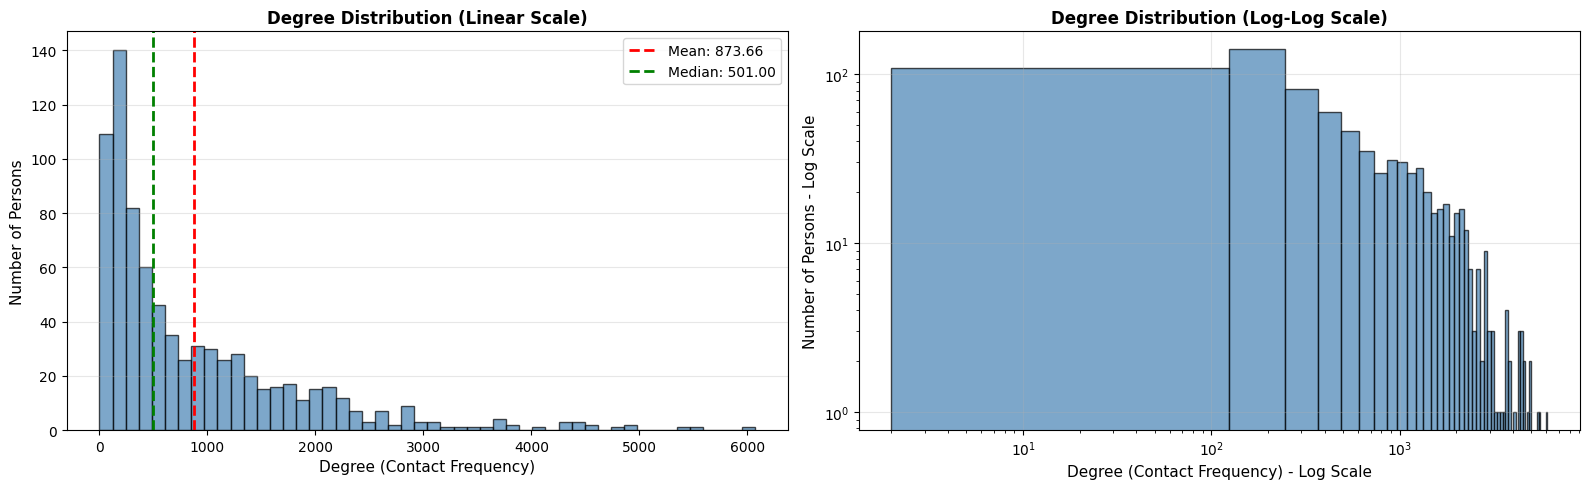

In [9]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(degree_count, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(degree_count.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {degree_count.mean():.2f}')
axes[0].axvline(degree_count.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {degree_count.median():.2f}')
axes[0].set_xlabel('Degree (Contact Frequency)', fontsize=11)
axes[0].set_ylabel('Number of Persons', fontsize=11)
axes[0].set_title('Degree Distribution (Linear Scale)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(degree_count, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Degree (Contact Frequency) - Log Scale', fontsize=11)
axes[1].set_ylabel('Number of Persons - Log Scale', fontsize=11)
axes[1].set_title('Degree Distribution (Log-Log Scale)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print(f"\nTop 15 Most Connected Persons:")
top_degree = degree_count.nlargest(15)
for idx, (person, count) in enumerate(top_degree.items(), 1):
    print(f"  {idx:2d}. Person {person:4} : {count:6.0f} contacts")


Top 15 Most Connected Persons:
   1. Person  884 :   6072 contacts
   2. Person  603 :   5533 contacts
   3. Person  122 :   5365 contacts
   4. Person  275 :   4952 contacts
   5. Person  513 :   4892 contacts
   6. Person  634 :   4738 contacts
   7. Person  147 :   4613 contacts
   8. Person   39 :   4531 contacts
   9. Person  366 :   4491 contacts
  10. Person    3 :   4412 contacts
  11. Person  267 :   4389 contacts
  12. Person 1359 :   4338 contacts
  13. Person  119 :   4290 contacts
  14. Person  255 :   4258 contacts
  15. Person 1512 :   4106 contacts


## 2.4 Group Homophily Analysis

<a id='24-group-homophily-analysis'></a>

Examine contact patterns within and between groups.

In [11]:
# Create homophily categories
df['contact_type'] = df.apply(
    lambda row: 'Intra-group' if row['group_A'] == row['group_B'] else 'Inter-group',
    axis=1
)

# Homophily statistics
homophily_counts = df['contact_type'].value_counts()
homophily_pct = df['contact_type'].value_counts(normalize=True) * 100

print(f"\nContact Type Distribution:")
for ctype in homophily_counts.index:
    print(f"  {ctype:15}: {homophily_counts[ctype]:7} ({homophily_pct[ctype]:6.2f}%)")


Contact Type Distribution:
  Intra-group    :  249240 ( 71.86%)
  Inter-group    :   97605 ( 28.14%)


In [12]:
# Group size distribution
group_persons_a = df['group_A'].value_counts()
group_persons_b = df['group_B'].value_counts()
group_contacts = group_persons_a.add(group_persons_b, fill_value=0).sort_values(ascending=False)

print(f"\nGroup Contact Distribution:")
for group, count in group_contacts.items():
    print(f"  {group:10}: {count:7.0f} contacts")


Group Contact Distribution:
  BIO       :  146155 contacts
  MPst      :   84447 contacts
  PC        :   53357 contacts
  PCst      :   41580 contacts
  DMI       :   36148 contacts
  MP        :   33440 contacts
  DSE       :   30960 contacts
  DMCT      :   24962 contacts
  DISQ      :   24283 contacts
  DST       :   24228 contacts
  PSIst     :   18037 contacts
  SRH       :   12262 contacts
  DCAR      :   10471 contacts
  SFLE      :    5233 contacts
  SSI       :    2857 contacts
  SCOM      :    2749 contacts
  SDOC      :    1498 contacts
  DG        :     501 contacts


In [13]:
# Inter-group contact matrix
print(f"\nInter-group Contact Matrix:")
inter_group_matrix = pd.crosstab(df['group_A'], df['group_B'])
print(inter_group_matrix)


Inter-group Contact Matrix:
group_B    BIO  DCAR  DG  DISQ  DMCT    DMI    DSE   DST     MP   MPst     PC  \
group_A                                                                         
BIO      72434     0   0     0     0      0      0     0     79    323     88   
DCAR         0  3768  11    85    72    442    166   260      0      0      0   
DG           0    44   6   100     5     93      1    53      0      0      0   
DISQ         0   164  67  9852   766    342    284   364      0      0      0   
DMCT         0    53   0   384  9888    355    789   549      0      0      0   
DMI          0   505  23   269   339  14945    308   757      0      0      0   
DSE          0    44   4   956   625    272  12348   270      0      0      0   
DST          0   298   5   244   463   1158   1038  8549      0      0      0   
MP          47     0   0     0     0      0      0     0  15070   2070     13   
MPst        11     0   0     0     0      0      0     0    709  40273      8   

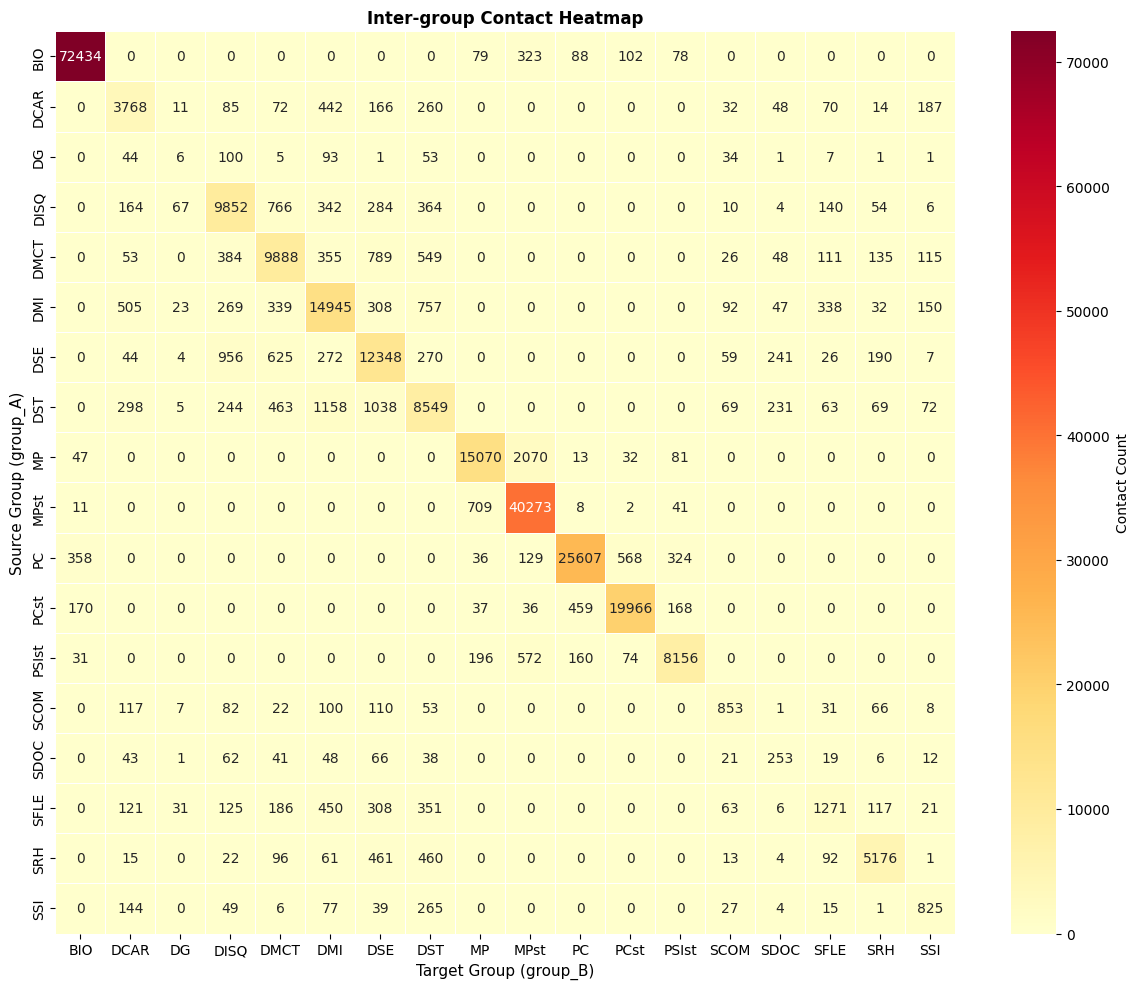

In [14]:
# Visualize inter-group contacts
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(inter_group_matrix, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Contact Count'}, ax=ax, linewidths=0.5)
ax.set_title('Inter-group Contact Heatmap', fontsize=12, fontweight='bold')
ax.set_xlabel('Target Group (group_B)', fontsize=11)
ax.set_ylabel('Source Group (group_A)', fontsize=11)
plt.tight_layout()
plt.show()

## 2.5 Temporal Pattern Analysis - Hourly Distribution

<a id='25-temporal-pattern-analysis'></a>

Analyze contact frequency patterns across different hours of the day.

In [15]:
print("\n" + "="*80)
print("TEMPORAL PATTERN ANALYSIS - HOURLY DISTRIBUTION")
print("="*80)

# Extract hour from datetime
df['hour'] = df['datetime'].dt.hour

# Hourly contact distribution
hourly_contacts = df['hour'].value_counts().sort_index()

print(f"\nHourly Contact Distribution:")
for hour, count in hourly_contacts.items():
    print(f"  Hour {hour:2d}:00 - {hour:2d}:59 : {count:6} contacts ({count/len(df)*100:5.2f}%)")


TEMPORAL PATTERN ANALYSIS - HOURLY DISTRIBUTION

Hourly Contact Distribution:
  Hour  8:00 -  8:59 :  24639 contacts ( 7.10%)
  Hour  9:00 -  9:59 :  34461 contacts ( 9.94%)
  Hour 10:00 - 10:59 :  41149 contacts (11.86%)
  Hour 11:00 - 11:59 :  47693 contacts (13.75%)
  Hour 12:00 - 12:59 :  39069 contacts (11.26%)
  Hour 13:00 - 13:59 :  40414 contacts (11.65%)
  Hour 14:00 - 14:59 :  38050 contacts (10.97%)
  Hour 15:00 - 15:59 :  31603 contacts ( 9.11%)
  Hour 16:00 - 16:59 :  31447 contacts ( 9.07%)
  Hour 17:00 - 17:59 :  10108 contacts ( 2.91%)
  Hour 18:00 - 18:59 :   5256 contacts ( 1.52%)
  Hour 19:00 - 19:59 :   2785 contacts ( 0.80%)
  Hour 20:00 - 20:59 :    124 contacts ( 0.04%)
  Hour 21:00 - 21:59 :     47 contacts ( 0.01%)


In [16]:
# Hourly statistics
print(f"\nHourly Statistics:")
print(f"  Mean contacts per hour: {hourly_contacts.mean():.2f}")
print(f"  Median contacts per hour: {hourly_contacts.median():.2f}")
print(f"  Peak hour: {hourly_contacts.idxmax()}:00 with {hourly_contacts.max()} contacts")
print(f"  Lowest hour: {hourly_contacts.idxmin()}:00 with {hourly_contacts.min()} contacts")
print(f"  Std Dev: {hourly_contacts.std():.2f}")


Hourly Statistics:
  Mean contacts per hour: 24774.64
  Median contacts per hour: 31525.00
  Peak hour: 11:00 with 47693 contacts
  Lowest hour: 21:00 with 47 contacts
  Std Dev: 17325.52


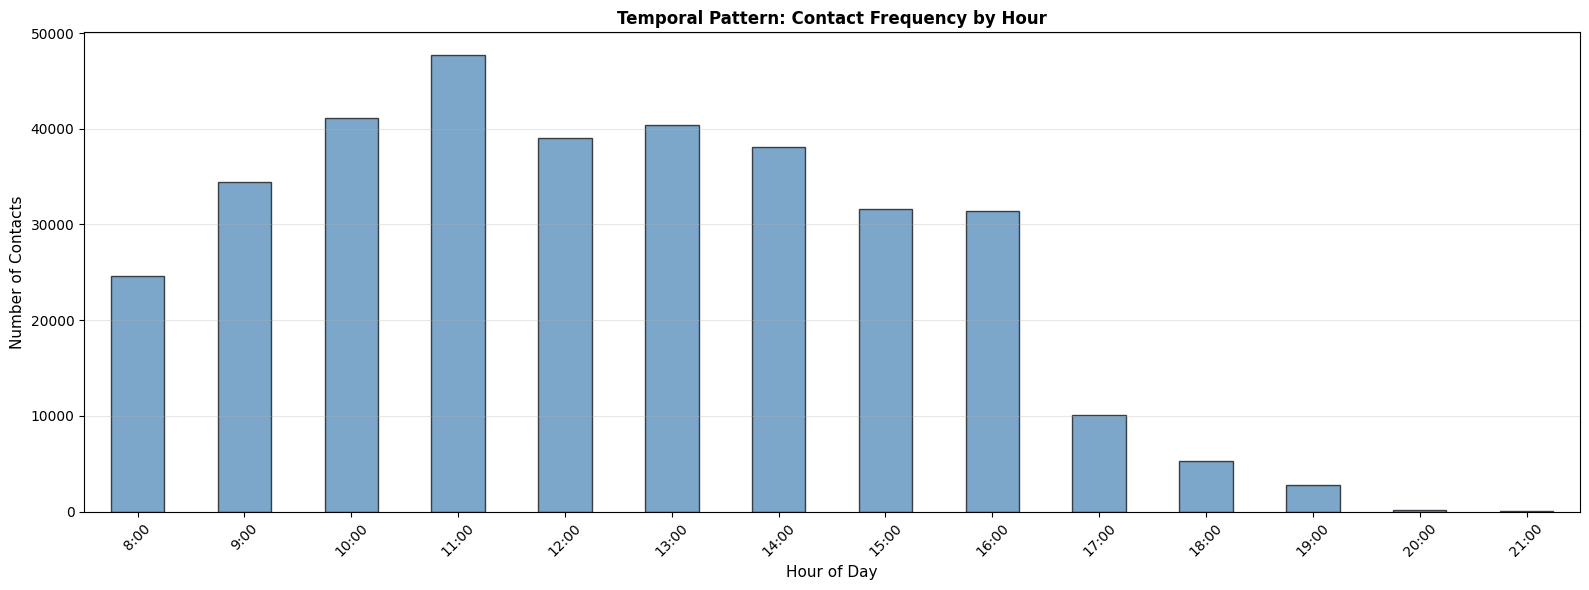

In [17]:
# Visualize hourly pattern
fig, ax = plt.subplots(figsize=(16, 6))
hourly_contacts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Number of Contacts', fontsize=11)
ax.set_title('Temporal Pattern: Contact Frequency by Hour', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(len(hourly_contacts.index))) # Set ticks at the position of each bar
ax.set_xticklabels([f'{i}:00' for i in hourly_contacts.index], rotation=45) # Set labels using the actual hours
plt.tight_layout()
plt.show()

## 2.6 Temporal Burstiness and Inter-event Time Distribution

<a id='26-temporal-burstiness-analysis'></a>

Analyze the time between consecutive contacts and calculate burstiness index.

In [18]:
# Sort by timestamp for inter-event analysis
df_sorted = df.sort_values('timestamp').reset_index(drop=True)

# Calculate inter-event times (time between consecutive contacts)
inter_event_times = np.diff(df_sorted['timestamp'].values)

print("\n" + "="*80)
print("TEMPORAL BURSTINESS AND INTER-EVENT TIME DISTRIBUTION")
print("="*80)

print(f"\nInter-event Time Distribution (seconds):")
print(f"  Mean: {inter_event_times.mean():.2f}s")
print(f"  Median: {np.median(inter_event_times):.2f}s")
print(f"  Std Dev: {inter_event_times.std():.2f}s")
print(f"  Min: {inter_event_times.min():.2f}s")
print(f"  Max: {inter_event_times.max():.2f}s")
print(f"  Skewness: {skew(inter_event_times):.4f}")


TEMPORAL BURSTINESS AND INTER-EVENT TIME DISTRIBUTION

Inter-event Time Distribution (seconds):
  Mean: 2.86s
  Median: 0.00s
  Std Dev: 426.63s
  Min: 0.00s
  Max: 218600.00s
  Skewness: 412.8403


In [19]:
# Burstiness index
mean_iet = inter_event_times.mean()
std_iet = inter_event_times.std()
burstiness = (std_iet - mean_iet) / (std_iet + mean_iet)

print(f"\nTemporal Burstiness Index: {burstiness:.4f}")
print("  Interpretation:")
print(f"    Range: [-1, 1]")
print(f"    0 = random (Poisson)")
print(f"    >0 = bursty (clustered)")
print(f"    <0 = regular (evenly spaced)")



Temporal Burstiness Index: 0.9867
  Interpretation:
    Range: [-1, 1]
    0 = random (Poisson)
    >0 = bursty (clustered)
    <0 = regular (evenly spaced)


## 2.7 Temporal Coverage and Gaps

<a id='27-temporal-coverage-and-gaps'></a>

Examine temporal coverage patterns across minutes, hours, and days.

In [20]:
print("\n" + "="*80)
print("TEMPORAL COVERAGE AND GAPS")
print("="*80)

# Group contacts by time windows
df['time_window_1min'] = df['datetime'].dt.floor('1min')
df['time_window_1hour'] = df['datetime'].dt.floor('1H')
df['date'] = df['datetime'].dt.date

# Contacts per minute
contacts_per_minute = df.groupby('time_window_1min').size()
print(f"\nContacts per Minute:")
print(f"  Total time windows (minutes) with contacts: {len(contacts_per_minute)}")
print(f"  Mean contacts per minute: {contacts_per_minute.mean():.2f}")
print(f"  Max contacts in a minute: {contacts_per_minute.max()}")


TEMPORAL COVERAGE AND GAPS

Contacts per Minute:
  Total time windows (minutes) with contacts: 6679
  Mean contacts per minute: 51.93
  Max contacts in a minute: 388


In [21]:
# Contacts per hour
contacts_per_hour = df.groupby('time_window_1hour').size()
print(f"\nContacts per Hour:")
print(f"  Total time windows (hours) with contacts: {len(contacts_per_hour)}")
print(f"  Mean contacts per hour: {contacts_per_hour.mean():.2f}")
print(f"  Max contacts in an hour: {contacts_per_hour.max()}")

# Contacts per day
contacts_per_day = df.groupby('date').size()
print(f"\nContacts per Day:")
print(f"  Total time windows (days) with contacts: {len(contacts_per_day)}")
print(f"  Mean contacts per day: {contacts_per_day.mean():.2f}")
print(f"  Max contacts in a day: {contacts_per_day.max()}")


Contacts per Hour:
  Total time windows (hours) with contacts: 122
  Mean contacts per hour: 2842.99
  Max contacts in an hour: 15465

Contacts per Day:
  Total time windows (days) with contacts: 10
  Mean contacts per day: 34684.50
  Max contacts in a day: 87876


In [22]:
# Contacts per date
contacts_per_date = df.groupby('date').size()
print(f"\nContacts per Date:")
print(f"  Total dates: {len(contacts_per_date)}")
print(f"  Mean contacts per date: {contacts_per_date.mean():.2f}")



Contacts per Date:
  Total dates: 10
  Mean contacts per date: 34684.50


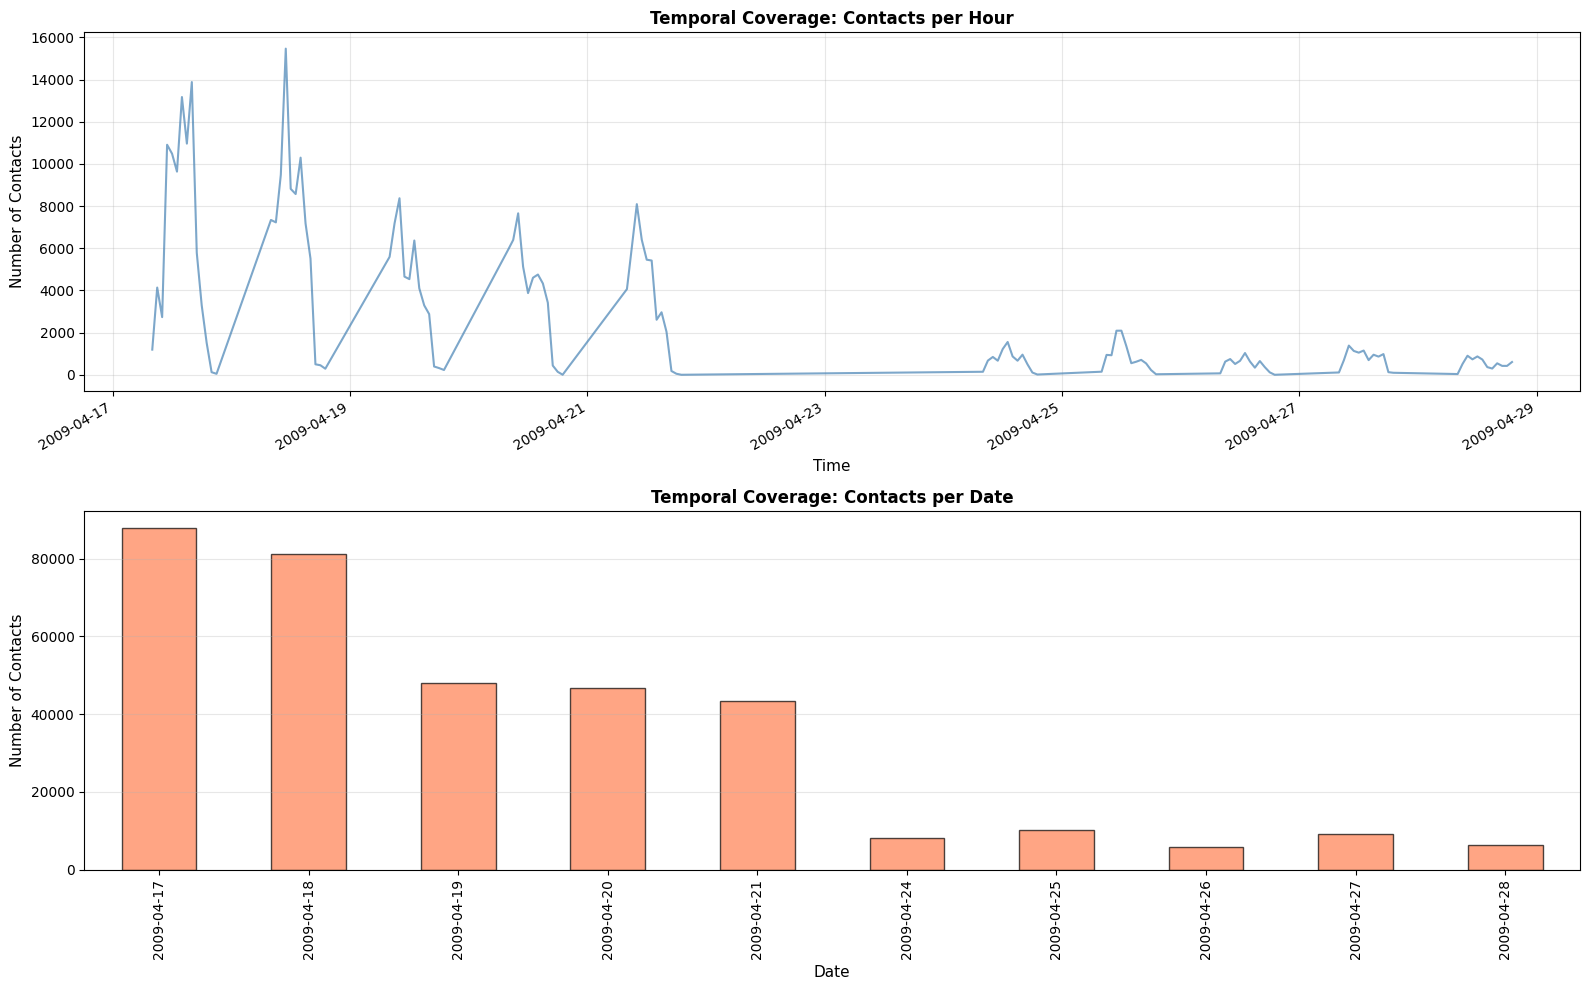

In [23]:
# Visualize temporal coverage
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Hourly coverage
contacts_per_hour.plot(ax=axes[0], color='steelblue', alpha=0.7, linewidth=1.5)
axes[0].set_xlabel('Time', fontsize=11)
axes[0].set_ylabel('Number of Contacts', fontsize=11)
axes[0].set_title('Temporal Coverage: Contacts per Hour', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Daily coverage
contacts_per_date.plot(ax=axes[1], kind='bar', color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Number of Contacts', fontsize=11)
axes[1].set_title('Temporal Coverage: Contacts per Date', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 2.8 Contacts per Person Distribution

<a id='28-contacts-per-person-distribution'></a>

Analyze the distribution of contact frequency across individuals.

In [24]:
print("\n" + "="*80)
print("CONTACTS PER PERSON DISTRIBUTION")
print("="*80)

# Calculate total contacts per unique person
all_contacts_a = df['person_A'].value_counts()
all_contacts_b = df['person_B'].value_counts()

# Combine (accounting for potential duplicates)
contacts_per_person = all_contacts_a.add(all_contacts_b, fill_value=0)

print(f"\nContacts per Person Statistics:")
print(f"  Mean: {contacts_per_person.mean():.2f}")
print(f"  Median: {contacts_per_person.median():.2f}")
print(f"  Std Dev: {contacts_per_person.std():.2f}")
print(f"  Min: {contacts_per_person.min():.0f}")
print(f"  Max: {contacts_per_person.max():.0f}")
print(f"  Skewness: {skew(contacts_per_person):.4f}")


CONTACTS PER PERSON DISTRIBUTION

Contacts per Person Statistics:
  Mean: 873.66
  Median: 501.00
  Std Dev: 954.97
  Min: 2
  Max: 6072
  Skewness: 1.9332


In [25]:
# Identify isolated vs highly connected
isolated = (contacts_per_person <= 1).sum()
highly_connected = (contacts_per_person >= contacts_per_person.quantile(0.9)).sum()
moderate = ((contacts_per_person > 1) & (contacts_per_person < contacts_per_person.quantile(0.9))).sum()

print(f"\nPerson Categories:")
print(f"  Isolated persons (≤1 contact): {isolated} ({isolated/len(contacts_per_person)*100:.2f}%)")
print(f"  Moderate persons: {moderate} ({moderate/len(contacts_per_person)*100:.2f}%)")
print(f"  Highly connected (top 10%): {highly_connected} ({highly_connected/len(contacts_per_person)*100:.2f}%)")


Person Categories:
  Isolated persons (≤1 contact): 0 (0.00%)
  Moderate persons: 714 (89.92%)
  Highly connected (top 10%): 80 (10.08%)


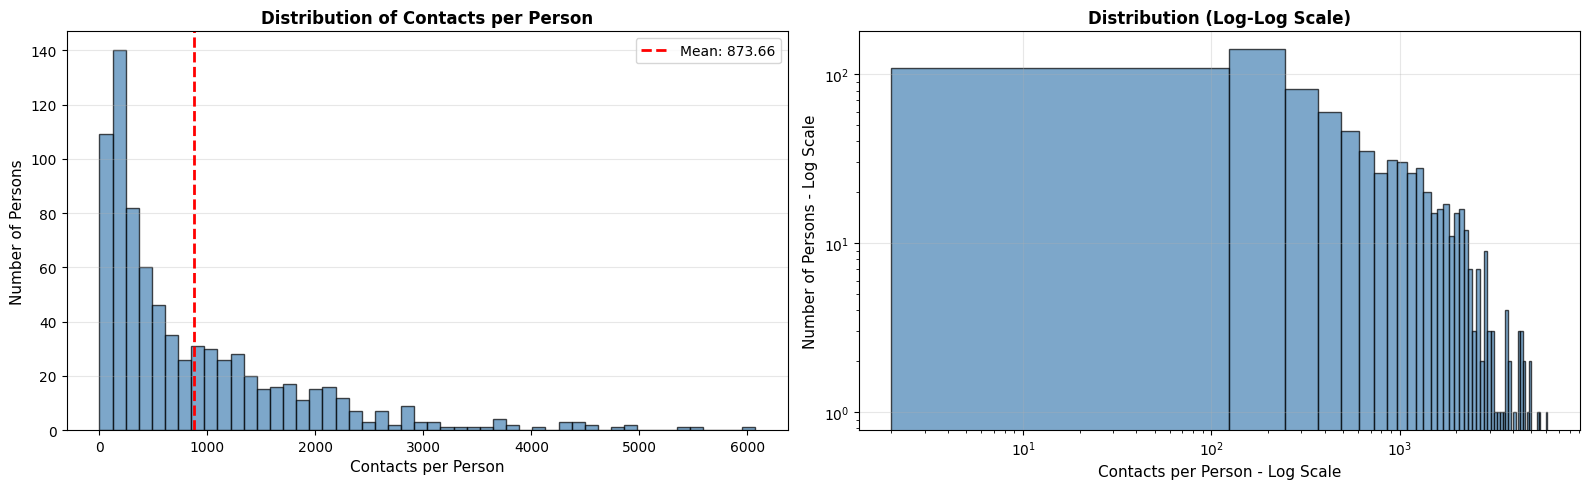

In [26]:
# Distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(contacts_per_person, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(contacts_per_person.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {contacts_per_person.mean():.2f}')
axes[0].set_xlabel('Contacts per Person', fontsize=11)
axes[0].set_ylabel('Number of Persons', fontsize=11)
axes[0].set_title('Distribution of Contacts per Person', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(contacts_per_person, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Contacts per Person - Log Scale', fontsize=11)
axes[1].set_ylabel('Number of Persons - Log Scale', fontsize=11)
axes[1].set_title('Distribution (Log-Log Scale)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Temporal Network Graph

<a id='3-temporal-network-graph'></a>

Build and visualize temporal network graph representations from contact data.

## 3.1 Build Temporal Network Graph - Node List

<a id='31-build-node-list'></a>

Create a comprehensive node list with attributes for graph construction.

In [27]:
print("\n" + "="*80)
print("GRAPH CONSTRUCTION: NODE LIST")
print("="*80)

# Create node list with attributes
nodes = []
for person in unique_persons:
    person_data = df[(df['person_A'] == person) | (df['person_B'] == person)]

    # Get group affiliation
    group_a = person_data['group_A'].mode()
    group_b = person_data['group_B'].mode()

    if len(group_a) > 0:
        group = group_a.values[0]
    elif len(group_b) > 0:
        group = group_b.values[0]
    else:
        group = 'Unknown'

    # Calculate contact statistics
    degree = len(person_data)
    first_contact = person_data['datetime'].min()
    last_contact = person_data['datetime'].max()
    duration_days = (last_contact - first_contact).total_seconds() / 86400

    nodes.append({
        'person_id': person,
        'group': group,
        'degree': degree,
        'first_contact': first_contact,
        'last_contact': last_contact,
        'duration_days': duration_days
    })

nodes_df = pd.DataFrame(nodes)

print(f"\nNode List Summary:")
print(f"  Total nodes: {len(nodes_df)}")
print(f"\nFirst 15 nodes:")
print(nodes_df.head(15).to_string(index=False))


GRAPH CONSTRUCTION: NODE LIST

Node List Summary:
  Total nodes: 794

First 15 nodes:
 person_id group  degree       first_contact        last_contact  duration_days
         1   BIO     367 2009-04-17 12:00:20 2009-04-18 10:08:20       0.922222
         3   BIO    4412 2009-04-17 08:15:20 2009-04-25 17:49:40       8.398843
         4 PSIst    1794 2009-04-17 12:13:00 2009-04-21 15:10:20       4.123148
         9    PC    1975 2009-04-17 12:00:20 2009-04-21 16:55:20       4.204861
        14  PCst     950 2009-04-17 08:54:20 2009-04-28 15:51:20      11.289583
        15    PC    2052 2009-04-17 08:01:40 2009-04-27 17:38:40      10.400694
        17  DMCT     104 2009-04-17 12:18:00 2009-04-28 09:44:40      10.893519
        18   SRH    1143 2009-04-17 09:27:20 2009-04-28 19:59:40      11.439120
        20  MPst    1779 2009-04-17 08:01:40 2009-04-28 17:23:00      11.389815
        21    PC    1140 2009-04-17 08:20:20 2009-04-28 12:09:40      11.159259
        27   BIO    1142 2009-04-

## 3.2 Build Temporal Network Graph - Edge List

<a id='32-build-edge-list'></a>

Create temporal and aggregated edge lists for network analysis.

In [28]:
# Create comprehensive edge list with temporal information
edges = []

for idx, row in df.iterrows():
    edges.append({
        'source': row['person_A'],
        'target': row['person_B'],
        'timestamp': row['timestamp'],
        'datetime': row['datetime'],
        'source_group': row['group_A'],
        'target_group': row['group_B'],
        'contact_type': row['contact_type'],
        'duration': 20  # 20-second resolution
    })

edges_df = pd.DataFrame(edges)

print(f"\nTemporal Edge List Summary:")
print(f"  Total temporal edges: {len(edges_df)}")
print(f"  Temporal resolution: 20 seconds")
print(f"\nFirst 15 temporal edges:")
print(edges_df.head(15).to_string(index=False))


Temporal Edge List Summary:
  Total temporal edges: 346845
  Temporal resolution: 20 seconds

First 15 temporal edges:
 source  target  timestamp            datetime source_group target_group contact_type  duration
    492     938    28820.0 2009-04-17 08:00:20          SRH         DMCT  Inter-group        20
    164     779    28840.0 2009-04-17 08:00:40          SSI          DST  Inter-group        20
    574    1362    28840.0 2009-04-17 08:00:40          DMI          DST  Inter-group        20
    117     429    28860.0 2009-04-17 08:01:00         SFLE          DST  Inter-group        20
    267     272    28860.0 2009-04-17 08:01:00          DSE          DSE  Intra-group        20
    447     763    28860.0 2009-04-17 08:01:00          DMI          DMI  Intra-group        20
    447     763    28880.0 2009-04-17 08:01:20          DMI          DMI  Intra-group        20
    215    1414    28900.0 2009-04-17 08:01:40          DST         SFLE  Inter-group        20
     97    1204 

In [29]:
# Create aggregated edge list (for static network reference)
print(f"\nCreating aggregated edge list...")
aggregated_edges = df.groupby(['person_A', 'person_B']).agg({
    'timestamp': ['min', 'max', 'count'],
    'group_A': 'first',
    'group_B': 'first',
    'contact_type': 'first'
}).reset_index()

aggregated_edges.columns = ['source', 'target', 'first_contact_time', 'last_contact_time',
                             'contact_count', 'source_group', 'target_group', 'contact_type']

print(f"\nAggregated Edge List Summary:")
print(f"  Unique edges: {len(aggregated_edges)}")
print(f"  Mean contacts per pair: {aggregated_edges['contact_count'].mean():.2f}")
print(f"  Max contacts per pair: {aggregated_edges['contact_count'].max():.0f}")
print(f"  Min contacts per pair: {aggregated_edges['contact_count'].min():.0f}")
print(f"\nFirst 15 aggregated edges:")
print(aggregated_edges.head(15).to_string(index=False))


Creating aggregated edge list...

Aggregated Edge List Summary:
  Unique edges: 20346
  Mean contacts per pair: 17.05
  Max contacts per pair: 2949
  Min contacts per pair: 1

First 15 aggregated edges:
 source  target  first_contact_time  last_contact_time  contact_count source_group target_group contact_type
      1      55             43260.0            48400.0              8          BIO          BIO  Intra-group
      1      63             47140.0            51100.0              2          BIO          BIO  Intra-group
      1     101             51100.0            51100.0              1          BIO          BIO  Intra-group
      1     106             46460.0            51100.0              4          BIO          BIO  Intra-group
      1     117             43580.0           122900.0             19          BIO          BIO  Intra-group
      1     170             45820.0            54700.0              8          BIO          BIO  Intra-group
      1     179             54760

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

## 3.3 Graph Construction and Visualization

<a id='33-graph-construction-and-visualization'></a>

Construct the network graph and prepare for centrality analysis.

In [2]:
# Load clean dataset
df = pd.read_csv("datasets/compiled_merged_dataset/final_contact_tracing_data.csv")

print("Initial Shape:", df.shape)
print(df.head(3))

Initial Shape: (346845, 13)
   timestamp  person_A  person_B group_A group_B  time_seconds  time_minutes  \
0    28820.0       492       938     SRH    DMCT        576400   9606.666667   
1    28840.0       164       779     SSI     DST        576800   9613.333333   
2    28840.0       574      1362     DMI     DST        576800   9613.333333   

   time_hours        source_file             datetime        date      hour  \
0  160.111111  tij_InVS13_merged  2009-04-17 08:00:20  2009-04-17  08:00:20   
1  160.222222         tij_InVS15  2009-04-17 08:00:40  2009-04-17  08:00:40   
2  160.222222         tij_InVS15  2009-04-17 08:00:40  2009-04-17  08:00:40   

   timestamp_norm  
0         0.00000  
1         0.00002  
2         0.00002  


In [3]:
df = df[['person_A', 'person_B']]

# Just in case: remove self-links and handle missing values
df = df.dropna(subset=['person_A', 'person_B'])
df = df[df['person_A'] != df['person_B']]

print("After cleaning:", df.shape)
print(df.head(3))

After cleaning: (346845, 2)
   person_A  person_B
0       492       938
1       164       779
2       574      1362


In [4]:
# Build Contact Graph
G = nx.Graph()

# Add edges from person_A to person_B contacts
edges = list(zip(df['person_A'], df['person_B']))
G.add_edges_from(edges)

print(f"Nodes: {G.number_of_nodes()}\nEdges: {G.number_of_edges()}")    

Nodes: 794
Edges: 20018


In [5]:
# Compute Degree Centrality
degree_centrality = nx.degree_centrality(G)
centrality_df = pd.DataFrame(list(degree_centrality.items()), columns=['Node', 'Centrality'])
centrality_df = centrality_df.sort_values(by='Centrality', ascending=False)

print("\nTop 10 Most Central Nodes:")
print(centrality_df.head(10))


Top 10 Most Central Nodes:
     Node  Centrality
175  1599    0.213115
393  1688    0.211854
264  1655    0.205549
270  1441    0.199243
274  1825    0.196721
221   275    0.161412
298  1458    0.160151
144  1485    0.157629
8     267    0.156368
284  1617    0.156368


# 4. Centrality Analysis

<a id='4-centrality-analysis'></a>

Identify key individuals in the contact network using centrality measures.

## 4.1 Degree Centrality

<a id='41-degree-centrality'></a>

Compute degree centrality to identify the most connected individuals.

## 4.2 Network Visualization with Superspreaders

<a id='42-network-visualization-with-superspreaders'></a>

Visualize the network highlighting superspreaders (top 5% by centrality).

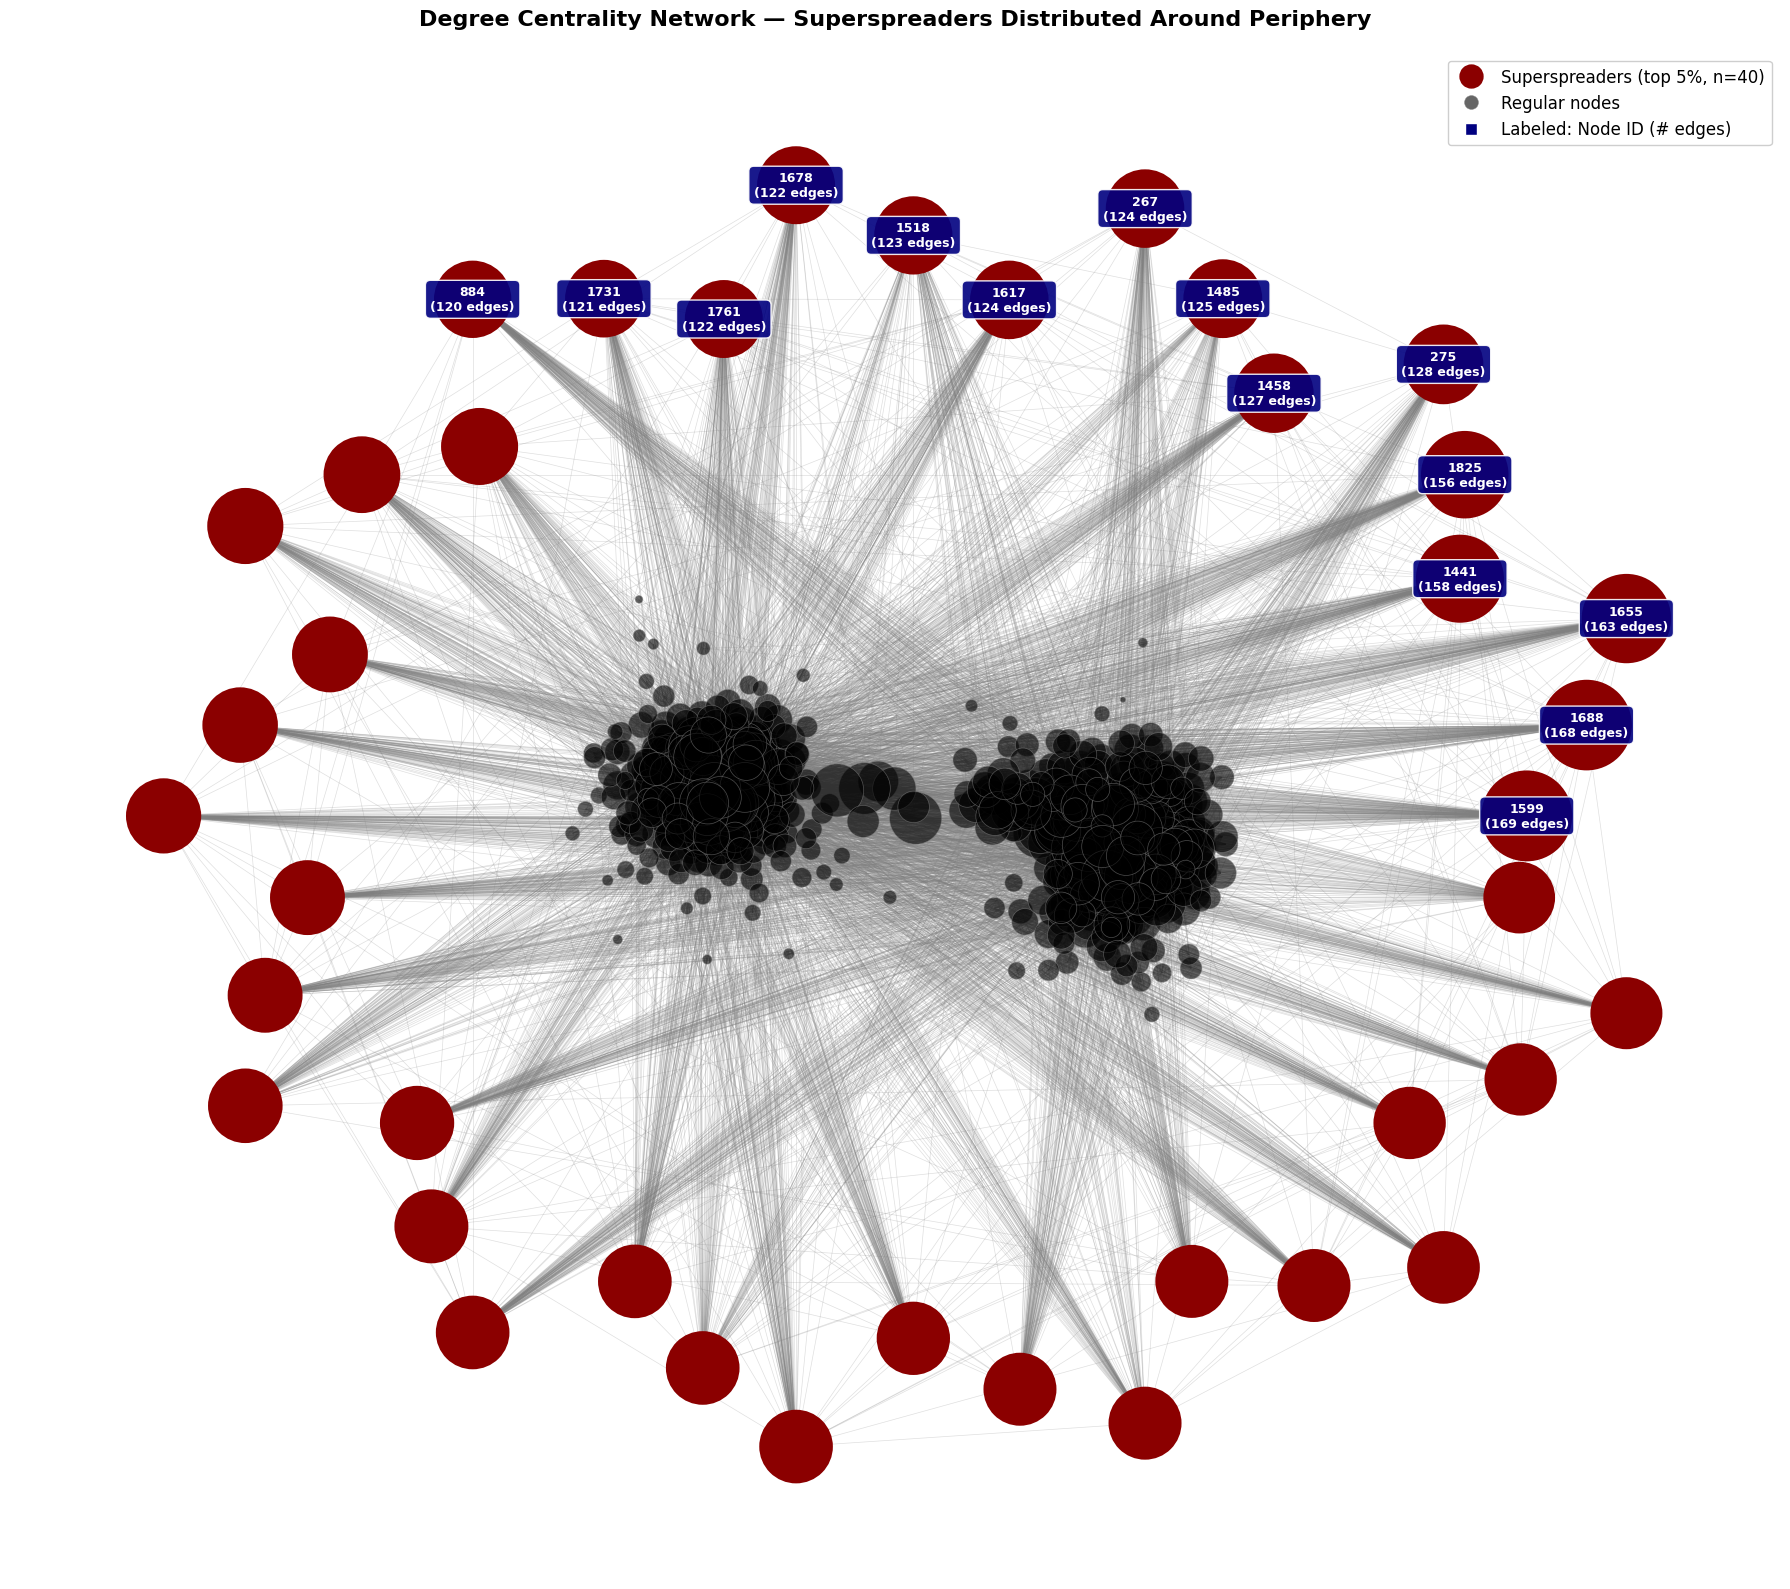

In [6]:
# Network Graph Visualization with Superspreaders Spread Across Canvas
plt.figure(figsize=(18, 16))

# Start with a normal layout for all nodes
pos = nx.spring_layout(G, seed=42, k=0.3, iterations=50)

# Identify superspreaders (top 5% of nodes by centrality)
centrality_threshold = centrality_df['Centrality'].quantile(0.95)
superspreaders = centrality_df[centrality_df['Centrality'] >= centrality_threshold]['Node'].tolist()

# Dramatically spread out superspreaders across the entire canvas
for i, node in enumerate(superspreaders):
    # Distribute superspreaders in a circular pattern around the periphery
    angle = 2 * np.pi * i / len(superspreaders)
    # Place them far from center (radius = 1.8 to 2.2)
    radius = 1.8 + 0.4 * (i % 3) / 2  # Vary radius slightly
    pos[node] = np.array([radius * np.cos(angle), radius * np.sin(angle)])

# Draw edges with better visibility
nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color='gray', width=0.5)

# Draw regular nodes in BLACK/DARK GRAY (clustered in center)
regular_nodes = [n for n in G.nodes() if n not in superspreaders]
regular_sizes = [degree_centrality[n] * 12000 for n in regular_nodes]

if regular_nodes:
    nx.draw_networkx_nodes(G, pos, nodelist=regular_nodes, 
                          node_size=regular_sizes, node_color='black',
                          alpha=0.6, edgecolors='gray', linewidths=0.5)

# Draw superspreaders in RED with thick borders (spread across canvas)
superspreader_sizes = [degree_centrality[n] * 18000 for n in superspreaders]

if superspreaders:
    nx.draw_networkx_nodes(G, pos, nodelist=superspreaders,
                          node_size=superspreader_sizes, node_color='darkred',
                          alpha=1.0, edgecolors='darkred', linewidths=3.5)

# Add labels for top 15 nodes showing ID and degree (number of connections)
top_15_nodes = centrality_df.head(15)['Node'].tolist()
labels = {node: f"{node}\n({G.degree(node)} edges)" for node in top_15_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold', 
                        font_color='white', 
                        bbox=dict(boxstyle='round,pad=0.4', facecolor='navy', 
                                 edgecolor='white', alpha=0.9))

# Add informative legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkred', 
           markersize=14, markeredgecolor='darkred', markeredgewidth=3.5,
           label=f'Superspreaders (top 5%, n={len(superspreaders)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
           markersize=10, markeredgecolor='gray', markeredgewidth=0.5, alpha=0.6,
           label='Regular nodes'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='navy', 
           markersize=8, markeredgecolor='white', markeredgewidth=1,
           label='Labeled: Node ID (# edges)')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12, framealpha=0.95)

plt.title("Degree Centrality Network — Superspreaders Distributed Around Periphery", 
          fontsize=16, fontweight='bold', pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()


In [2]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import community.community_louvain as community_louvain
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity

# 5. Community Detection

<a id='5-community-detection'></a>

Detect and analyze community structures within the contact network using the Louvain algorithm.

## 5.1 Data Preparation for Graph Construction

<a id='51-data-preparation'></a>

This step loads and preprocesses the dataset for community detection analysis.  
We retain only the necessary columns (`person_A`, `person_B`), remove self-loops, and aggregate repeated contacts to form weighted edges.  
The result is an undirected weighted graph `G`, ready for algorithms such as Louvain community detection.

In [3]:

# Load dataset
df = pd.read_csv('datasets/compiled_merged_dataset/final_contact_tracing_data.csv')

# Keep only necessary columns
df = df[['person_A', 'person_B']]

# Remove self-loops
df = df[df['person_A'] != df['person_B']]

# Aggregate repeated contacts as edge weights
edge_df = df.groupby(['person_A', 'person_B']).size().reset_index(name='weight')

# Create an undirected weighted graph
G = nx.Graph()

# Add edges with weights
for _, row in edge_df.iterrows():
    G.add_edge(row['person_A'], row['person_B'], weight=row['weight'])

# Display summary
print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

# (Optional) Preview a few weighted edges
print(edge_df.head())

Nodes: 794 | Edges: 20018
   person_A  person_B  weight
0         1        55       8
1         1        63       2
2         1       101       1
3         1       106       4
4         1       117      19


## 5.2 Louvain Community Detection

<a id='52-louvain-community-detection'></a>

This step applies the **Louvain algorithm** to identify communities within the graph based on edge weights.  
Each node is assigned to a community that maximizes **modularity**, indicating densely connected groups.  
The resulting partition is added as a node attribute and stored in a DataFrame for further analysis or visualization.

In [4]:
# Run Louvain community detection
partition = community_louvain.best_partition(G, weight='weight')

# Add community info to node attributes
nx.set_node_attributes(G, partition, 'community')

# Convert to DataFrame
community_df = pd.DataFrame(list(partition.items()), columns=['Person', 'Community'])
print(community_df.head())
print(f"\nTotal number of detected communities: {community_df['Community'].nunique()}")

   Person  Community
0       1          0
1      55          0
2      63          1
3     101          1
4     106          2

Total number of detected communities: 13


## 5.3 Community Visualization

<a id='53-community-visualization'></a>

This section visualizes the detected communities from the Louvain algorithm.  
Each node is colored according to its community assignment, while edges represent connections between individuals.  
The spring layout positions nodes to highlight clusters, making community structures easier to interpret.

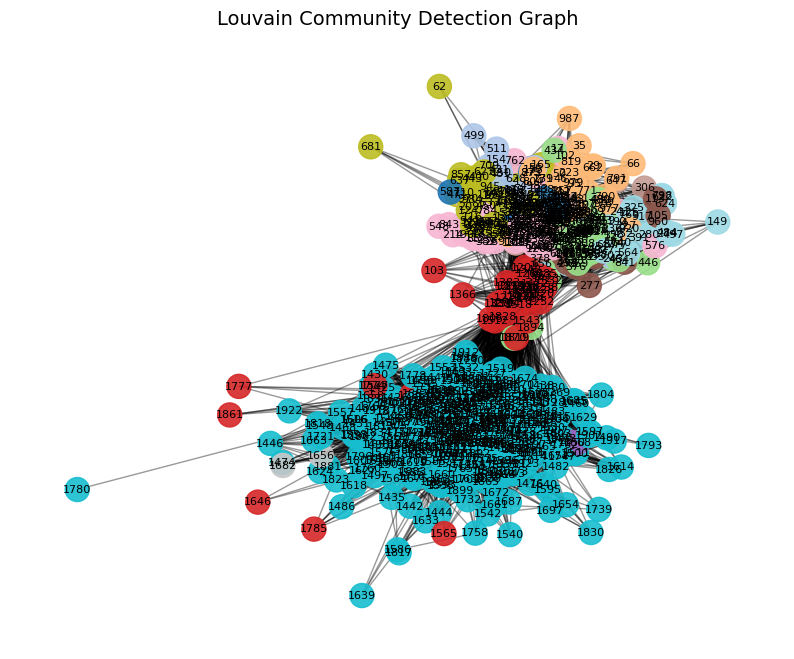

In [5]:
# --- Define Layout for Graph ---
pos = nx.spring_layout(G, seed=42)  # or nx.kamada_kawai_layout(G) for smoother spacing

# --- Draw Graph ---
plt.figure(figsize=(10, 8))

# Draw nodes — color by community
nx.draw_networkx_nodes(
    G, pos,
    node_size=300,
    node_color=list(partition.values()),
    cmap=plt.cm.tab20,
    alpha=0.9
)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.4)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Louvain Community Detection Graph", fontsize=14)
plt.axis("off")
plt.show()

## 5.4 Community Size Distribution

<a id='54-community-size-distribution'></a>

This section summarizes and visualizes the number of members in each detected community.  
By counting nodes assigned to each community, we can observe the relative sizes of clusters and identify dominant or smaller groups within the network.  
The bar chart below provides an overview of how evenly or unevenly individuals are distributed across communities.

Community Size Summary:
    Community  count
8           0     28
9           1     28
1           2     63
4           3     50
5           4     44
11          5      3
10          6     17
3           7     52
2           8     59
12          9      2
6          10     39
0          11    376
7          12     33


/var/folders/4d/c9fb2t_j5znf_ftgytncz11h0000gp/T/ipykernel_13955/2986095429.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


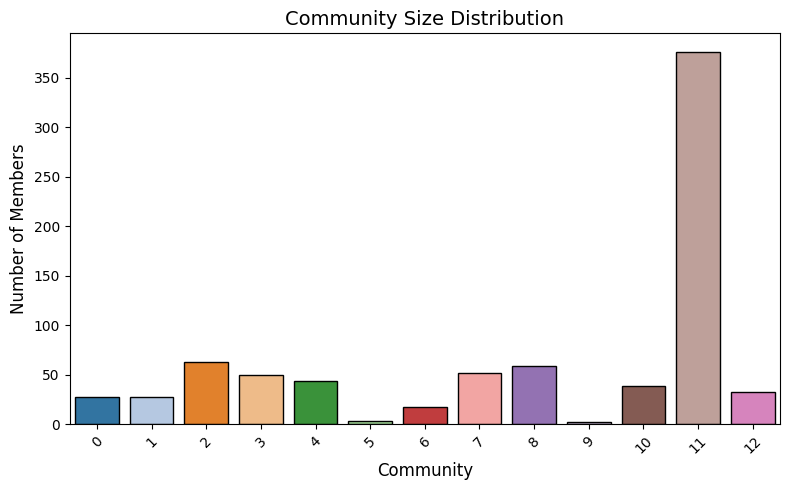

In [6]:
# --- Compute Community Sizes ---
community_sizes = (
    community_df['Community']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'community', 'community': 'size'})
    .sort_values('Community')
)

# --- Display Summary ---
print("Community Size Summary:")
print(community_sizes)

# --- Plot Community Size Distribution ---
plt.figure(figsize=(8, 5))
sns.barplot(
    data=community_sizes,
    x='Community',
    y='count',
    palette='tab20',
    edgecolor='black'
)
plt.title("Community Size Distribution", fontsize=14)
plt.xlabel("Community", fontsize=12)
plt.ylabel("Number of Members", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5.5 Community Detection Metrics

<a id='55-community-detection-metrics'></a>

This section evaluates the quality of the detected communities using key **network metrics**:

- **Modularity:** Measures how well the graph is divided into communities, with higher values indicating denser intra-community connections and fewer inter-community links.  
- **Coverage:** Represents the fraction of edges that lie within the detected communities.  
- **Performance:** Evaluates the proportion of correctly classified node pairs — connected within the same community or disconnected across different ones.  

Together, these metrics help assess how effectively the Louvain algorithm has identified meaningful community structures in the network.

In [7]:
import networkx as nx
from community import community_louvain
from networkx.algorithms.community import modularity
from collections import defaultdict
import itertools
import pandas as pd

# --- Run Louvain again if needed ---
partition = community_louvain.best_partition(G, weight='weight')

# --- Convert partition dict to list of sets for metric calculations ---
community_groups = defaultdict(set)
for node, comm in partition.items():
    community_groups[comm].add(node)
communities = list(community_groups.values())

# --- 1️⃣ Modularity ---
mod_score = modularity(G, communities, weight='weight')
print(f"Modularity: {mod_score:.4f}")

# --- 2️⃣ Coverage (manual implementation) ---
# Fraction of edges that fall within communities
intra_edges = sum(
    1 for u, v in G.edges()
    if partition[u] == partition[v]
)
cov_score = intra_edges / G.number_of_edges()
print(f"Coverage: {cov_score:.4f}")

# --- 3️⃣ Performance (manual implementation) ---
# Fraction of correctly classified pairs
def compute_performance(G, partition):
    nodes = list(G.nodes())
    correct = 0
    total = 0
    for u, v in itertools.combinations(nodes, 2):
        same_comm = partition[u] == partition[v]
        connected = G.has_edge(u, v)
        # correct if connected within community OR not connected across communities
        if (same_comm and connected) or (not same_comm and not connected):
            correct += 1
        total += 1
    return correct / total

perf_score = compute_performance(G, partition)
print(f"Performance: {perf_score:.4f}")



Modularity: 0.6573
Coverage: 0.6343
Performance: 0.7548


In [ ]:
!pip install networkx==3.1 python-louvain scikit-learn matplotlib pandas tqdm node2vec

# 6. Link Prediction

<a id='6-link-prediction'></a>

Predict potential future connections in the contact network using heuristic methods and machine learning.

## 6.1 Setup and Dependencies

<a id='61-setup-and-dependencies'></a>

Install and import required libraries for link prediction analysis.

In [ ]:
import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from collections import defaultdict
import community as community_louvain
from tqdm import tqdm
from node2vec import Node2Vec

## 6.2 Data Loading

<a id='62-data-loading'></a>

Load the contact tracing dataset and prepare it for link prediction.

In [ ]:
csv_path = "/content/final_contact_tracing_data.csv"
df = pd.read_csv(csv_path)

print("Columns detected:", df.columns.tolist())
print("First 5 rows:")
display(df.head())


Columns detected: ['timestamp', 'person_A', 'person_B', 'group_A', 'group_B', 'time_seconds', 'time_minutes', 'time_hours', 'source_file', 'datetime', 'date', 'hour', 'timestamp_norm']
First 5 rows:


,timestamp,person_A,person_B,group_A,group_B,time_seconds,time_minutes,time_hours,source_file,datetime,date,hour,timestamp_norm
0,28820.0,492,938,SRH,DMCT,576400,9606.666667,160.111111,tij_InVS13_merged,2009-04-17 08:00:20,2009-04-17,08:00:20,0.00000
1,28840.0,164,779,SSI,DST,576800,9613.333333,160.222222,tij_InVS15,2009-04-17 08:00:40,2009-04-17,08:00:40,0.00002
2,28840.0,574,1362,DMI,DST,576800,9613.333333,160.222222,tij_InVS15,2009-04-17 08:00:40,2009-04-17,08:00:40,0.00002
3,28860.0,117,429,SFLE,DST,577200,9620.000000,160.333333,tij_InVS15,2009-04-17 08:01:00,2009-04-17,08:01:00,0.00004
4,28860.0,267,272,DSE,DSE,577200,9620.000000,160.333333,tij_InVS13_merged,2009-04-17 08:01:00,2009-04-17,08:01:00,0.00004


In [ ]:
# === Build the Graph from your CSV edge list ===
G = nx.Graph()
G.add_edges_from(edges)
print("Original graph nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

# Extract the largest connected component (most real-world data has isolates)
Gc = max(nx.connected_components(G), key=len)
Gc = G.subgraph(Gc).copy()
print("Largest connected component nodes:", Gc.number_of_nodes(), "edges:", Gc.number_of_edges())

# Compute layout once for consistent plotting
pos = nx.spring_layout(Gc, seed=42)


Original graph nodes: 794 edges: 20018
Largest connected component nodes: 794 edges: 20018


In [ ]:

# Heuristic: find two columns that look like node pairs.
possible_names = ['source','target','from','to','u','v','node1','node2','person_a','person_b','src','dst']

# find two columns automatically
source_col, target_col = None, None
for c in df.columns:
    cl = c.lower()
    if cl in possible_names:
        if source_col is None:
            source_col = c
        elif target_col is None and c != source_col:
            target_col = c
if source_col is None or target_col is None:
    # fallback: use first two columns
    source_col, target_col = df.columns[0], df.columns[1]
    print(f"Falling back to first two columns as edge list: {source_col}, {target_col}")
else:
    print(f"Using columns for edges: {source_col}, {target_col}")

edges = df[[source_col, target_col]].dropna().astype(str).values.tolist()
print(f"Loaded {len(edges)} edges (rows).")

Using columns for edges: person_A, person_B
Loaded 346845 edges (rows).


## 6.3 Graph Construction

<a id='63-graph-construction'></a>

Build the graph from edge list and extract the largest connected component.

In [ ]:
# Prepare positive and negative samples for link prediction
import random
random.seed(42)
np.random.seed(42)

G_lp = Gc.copy()
all_edges = list(G_lp.edges())

# Identify bridge edges (removing them would disconnect the graph)
bridges = set(nx.bridges(G_lp))
non_bridge_edges = [e for e in all_edges if e not in bridges and (e[1], e[0]) not in bridges]

print("Total edges:", len(all_edges))
print("Bridges:", len(bridges))
print("Removable (non-bridge) edges:", len(non_bridge_edges))

# Select 20% of edges (non-bridges) as test positives
test_frac = 0.2
num_test_pos = max(1, int(len(all_edges) * test_frac))
test_pos_edges = random.sample(non_bridge_edges, num_test_pos)

# Create training graph by removing test edges
G_train = G_lp.copy()
G_train.remove_edges_from(test_pos_edges)

print("Training edges:", G_train.number_of_edges())
print("Testing positive edges:", len(test_pos_edges))

# Generate negative edges (pairs of nodes not connected)
non_edges = list(nx.non_edges(G_train))
test_neg_edges = random.sample(non_edges, len(test_pos_edges))

print("Testing negative edges:", len(test_neg_edges))


Total edges: 20018
Bridges: 1
Removable (non-bridge) edges: 20017
Training edges: 16015
Testing positive edges: 4003
Testing negative edges: 4003


## 6.4 Prepare Training and Test Data

<a id='64-prepare-training-and-test-data'></a>

Split edges into training and test sets, and generate negative samples for evaluation.

In [ ]:
# Heuristic link predictors and evaluation
def predict_scores_heuristic(G, edge_list, method='common_neighbors'):
    scores = []
    if method == 'common_neighbors':
        for u,v in edge_list:
            cn = len(list(nx.common_neighbors(G, u, v)))
            scores.append(cn)
    elif method == 'jaccard':
        for u,v in edge_list:
            # Jaccard coefficient generator returns (u,v,score)
            jc = next(nx.jaccard_coefficient(G, [(u,v)]))[2]
            scores.append(jc)
    elif method == 'adamic_adar':
        for u,v in edge_list:
            aa = next(nx.adamic_adar_index(G, [(u,v)]))[2]
            scores.append(aa)
    elif method == 'pref_attachment':
        for u,v in edge_list:
            pa = next(nx.preferential_attachment(G, [(u,v)]))[2]
            scores.append(pa)
    elif method == 'resource_allocation':
        for u,v in edge_list:
            ra = next(nx.resource_allocation_index(G, [(u,v)]))[2]
            scores.append(ra)
    else:
        raise ValueError("Unknown method")
    return np.array(scores, dtype=float)

# prepare test lists
test_pos = test_pos_edges
test_neg = test_neg_edges
test_pairs = test_pos + test_neg
y_true = np.array([1]*len(test_pos) + [0]*len(test_neg))

methods = ['common_neighbors','jaccard','adamic_adar','pref_attachment','resource_allocation']
results = {}
for m in methods:
    scores = predict_scores_heuristic(G_train, test_pairs, method=m)
    # some methods produce all zeros for sparse graphs; but AUC handles that
    try:
        auc = roc_auc_score(y_true, scores)
        ap = average_precision_score(y_true, scores)
    except Exception as e:
        auc = None
        ap = None
    results[m] = {'auc': auc, 'ap': ap}
    print(f"{m}: AUC={auc}, AP={ap}")

# Summary
import pandas as pd
print("\nSummary:")
display(pd.DataFrame(results).T)


common_neighbors: AUC=0.9132625299948345, AP=0.8896364012502652
jaccard: AUC=0.9118287751835386, AP=0.8961093550097392
adamic_adar: AUC=0.915583578366687, AP=0.8981229377044393
pref_attachment: AUC=0.7225789438835187, AP=0.6948427570487261
resource_allocation: AUC=0.9175778982650346, AP=0.9009894214802925

Summary:


,auc,ap
common_neighbors,0.913263,0.889636
jaccard,0.911829,0.896109
adamic_adar,0.915584,0.898123
pref_attachment,0.722579,0.694843
resource_allocation,0.917578,0.900989


## 6.5 Heuristic Link Predictors

<a id='65-heuristic-link-predictors'></a>

Evaluate heuristic-based link prediction methods (common neighbors, Jaccard, Adamic-Adar, etc.).

In [ ]:
# Node2Vec embeddings + logistic regression classifier
# Create node2vec walks on G_train and learn embeddings, then create feature vectors for node-pairs by concatenation or Hadamard.
node2vec = Node2Vec(G_train, dimensions=64, walk_length=30, num_walks=100, workers=2, seed=42)
model = node2vec.fit(window=10, min_count=1, batch_words=4)  # gensim Word2Vec model

# Build embedding dict
emb = {str(n): model.wv.get_vector(str(n)) if str(n) in model.wv else np.zeros(64) for n in G_train.nodes()}

def pair_features(u, v, emb, method='hadamard'):
    eu = emb[str(u)]
    ev = emb[str(v)]
    if method == 'hadamard':
        return eu * ev
    elif method == 'concat':
        return np.concatenate([eu, ev])
    elif method == 'average':
        return (eu + ev) / 2.0
    elif method == 'absdiff':
        return np.abs(eu - ev)
    else:
        raise ValueError("Unknown method")

# create feature matrix for classifier (use concat or hadamard)
feat_method = 'hadamard'
X = np.vstack([pair_features(u,v,emb, feat_method) for (u,v) in test_pairs])
y = y_true

# Train/test split for classifier demonstration: we'll split test_pairs into classifier train/test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_clf, y_train_clf)
y_scores = clf.predict_proba(X_test_clf)[:,1]
auc_clf = roc_auc_score(y_test_clf, y_scores)
ap_clf = average_precision_score(y_test_clf, y_scores)
print("Node2Vec + LogisticRegression: AUC=", auc_clf, "AP=", ap_clf)


Computing transition probabilities:   0%|          | 0/794 [00:00<?, ?it/s]

Node2Vec + LogisticRegression: AUC= 0.8267402262904512 AP= 0.7820498117019925


## 6.6 Node2Vec Embeddings

<a id='66-node2vec-embeddings'></a>

Train Node2Vec embeddings and use them with logistic regression for link prediction.

In [ ]:
# Precision@K helper and applying to all methods
def precision_at_k(y_true, scores, k):
    # returns precision among top-k predicted edges by score
    idx = np.argsort(scores)[::-1][:k]
    return np.mean(y_true[idx])

K = 50  # choose K meaningful for your test size
eval_table = []
for m in methods:
    scores = predict_scores_heuristic(G_train, test_pairs, method=m)
    auc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)
    pk = precision_at_k(y_true, scores, min(K, len(scores)))
    eval_table.append({'method': m, 'auc': auc, 'ap': ap, 'prec@K': pk})

# Add embedding classifier result
# For embedding classifier, compute on all test_pairs (not sampled split). For fairness, using classifier on X built from test_pairs.
X_all = np.vstack([pair_features(u,v,emb, feat_method) for (u,v) in test_pairs])
clf_scores_all = clf.predict_proba(X_all)[:,1]
eval_table.append({'method': 'node2vec_logreg', 'auc': roc_auc_score(y_true, clf_scores_all), 'ap': average_precision_score(y_true, clf_scores_all), 'prec@K': precision_at_k(y_true, clf_scores_all, min(K, len(clf_scores_all)))})

eval_df = pd.DataFrame(eval_table).sort_values('auc', ascending=False)
display(eval_df)


,method,auc,ap,prec@K
4,resource_allocation,0.917578,0.900989,0.96
2,adamic_adar,0.915584,0.898123,0.96
0,common_neighbors,0.913263,0.889636,0.96
1,jaccard,0.911829,0.896109,0.98
5,node2vec_logreg,0.834478,0.786066,0.94
3,pref_attachment,0.722579,0.694843,0.82


## 6.7 Model Evaluation

<a id='67-model-evaluation'></a>

Compare all link prediction methods using AUC, Average Precision, and Precision@K metrics.

Best method according to AUC: resource_allocation


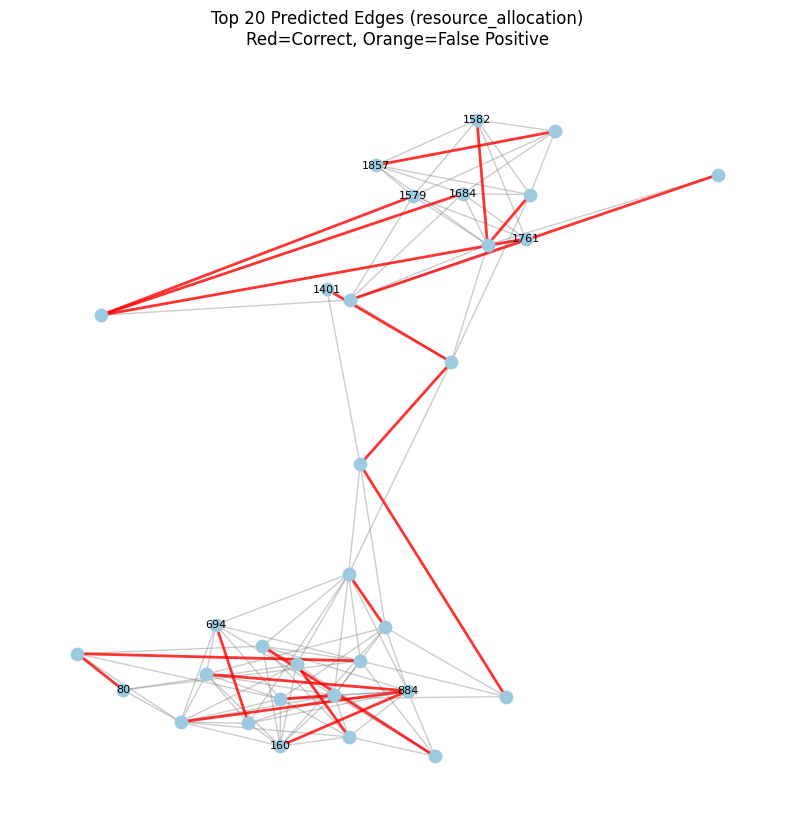

Top Predicted Links:
1441 - 1857 | score=1.4006 | true_label=1
1688 - 1684 | score=1.0477 | true_label=1
160 - 884 | score=1.0089 | true_label=1
1579 - 1688 | score=0.9701 | true_label=1
147 - 3 | score=0.9421 | true_label=1
80 - 285 | score=0.9054 | true_label=1
387 - 376 | score=0.8959 | true_label=1
1562 - 1825 | score=0.8903 | true_label=1
1761 - 1688 | score=0.8702 | true_label=1
1582 - 1825 | score=0.8577 | true_label=1
1518 - 1401 | score=0.8559 | true_label=1
295 - 884 | score=0.8427 | true_label=1
706 - 285 | score=0.8275 | true_label=1
20 - 290 | score=0.8252 | true_label=1
372 - 884 | score=0.8205 | true_label=1
119 - 63 | score=0.8191 | true_label=1
1655 - 1786 | score=0.8162 | true_label=1
1518 - 376 | score=0.8137 | true_label=1
272 - 275 | score=0.7892 | true_label=1
156 - 694 | score=0.7869 | true_label=1


In [ ]:
# ======  Visualization for Link Prediction Results ======
best_method = eval_df.iloc[0]['method']
print("Best method according to AUC:", best_method)

# Get scores from best model
if best_method == 'node2vec_logreg':
    scores = clf_scores_all
else:
    scores = predict_scores_heuristic(G_train, test_pairs, method=best_method)

# Sort predictions by confidence score
pairs_scores = list(zip(test_pairs, scores, y_true))
pairs_scores_sorted = sorted(pairs_scores, key=lambda x: x[1], reverse=True)
top_show = pairs_scores_sorted[:20]  # top 20 predictions

# --- Build a smaller subgraph for visualization ---
# Collect nodes involved in top predicted pairs
sub_nodes = set()
for (u, v), score, label in top_show:
    sub_nodes.add(u)
    sub_nodes.add(v)

# Extract subgraph containing those nodes
G_sub = G_train.subgraph(sub_nodes).copy()

# Recompute layout for small graph (better spacing)
pos_sub = nx.spring_layout(G_sub, seed=42, k=0.5)

plt.figure(figsize=(10, 10))
# Draw base subgraph (existing edges)
nx.draw_networkx_nodes(G_sub, pos_sub, node_size=80, node_color="#9ecae1")
nx.draw_networkx_edges(G_sub, pos_sub, width=1.0, alpha=0.4, edge_color="gray")

# Highlight top predicted links (solid for real missing edges, dashed for false)
for (u, v), score, label in top_show:
    if u in pos_sub and v in pos_sub:
        if label == 1:
            linestyle = '-'
            color = 'red'   # truly missing but real edge (good prediction)
        else:
            linestyle = '--'
            color = 'orange'  # predicted but actually false (false positive)
        nx.draw_networkx_edges(
            G_sub, pos_sub, edgelist=[(u, v)],
            width=2.0, style=linestyle, edge_color=color, alpha=0.8
        )

# Draw labels only for key nodes
top_nodes = list(sub_nodes)[:10]
nx.draw_networkx_labels(G_sub, pos_sub, labels={n: str(n) for n in top_nodes}, font_size=8)

plt.title(f"Top {len(top_show)} Predicted Edges ({best_method})\nRed=Correct, Orange=False Positive")
plt.axis('off')
plt.show()

# Print details for top predicted links
print("Top Predicted Links:")
for (u, v), score, label in top_show:
    print(f"{u} - {v} | score={score:.4f} | true_label={label}")


## 6.8 Visualization

<a id='68-visualization'></a>

Visualize the top predicted links and their accuracy, highlighting true positives and false positives.

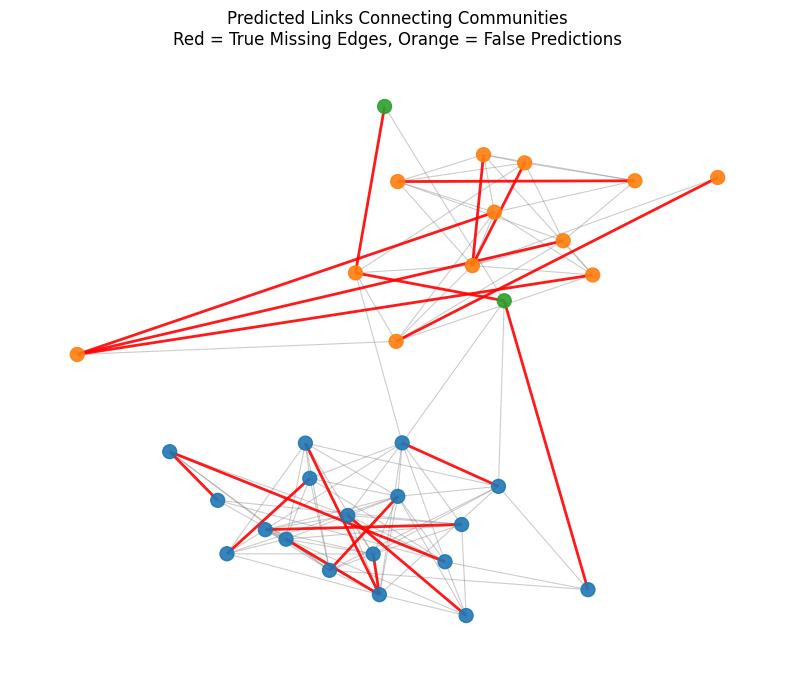

In [ ]:
# Clustered Subgraph Visualization ======
import matplotlib.cm as cm

best_method = eval_df.iloc[0]['method']
if best_method == 'node2vec_logreg':
    scores = clf_scores_all
else:
    scores = predict_scores_heuristic(G_train, test_pairs, method=best_method)

pairs_scores = list(zip(test_pairs, scores, y_true))
pairs_scores_sorted = sorted(pairs_scores, key=lambda x: x[1], reverse=True)
top_show = pairs_scores_sorted[:20]

# Collect nodes from top predicted pairs
sub_nodes = set([n for (u, v), _, _ in top_show for n in (u, v)])
G_sub = G_train.subgraph(sub_nodes).copy()

# Compute communities to color nodes
from networkx.algorithms import community
communities = list(community.greedy_modularity_communities(G_sub))
comm_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        comm_map[node] = i

colors = [cm.tab10(comm_map[n] % 10) for n in G_sub.nodes()]
pos_sub = nx.spring_layout(G_sub, seed=42, k=0.8)

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G_sub, pos_sub, node_size=100, node_color=colors, alpha=0.9)
nx.draw_networkx_edges(G_sub, pos_sub, width=0.8, alpha=0.4, edge_color="gray")

# Add predicted links
for (u, v), score, label in top_show:
    if u in G_sub and v in G_sub:
        color = "red" if label == 1 else "orange"
        style = "-" if label == 1 else "--"
        nx.draw_networkx_edges(
            G_sub, pos_sub, edgelist=[(u, v)],
            width=2.0, style=style, edge_color=color, alpha=0.9
        )

plt.title("Predicted Links Connecting Communities\nRed = True Missing Edges, Orange = False Predictions")
plt.axis("off")
plt.show()